In [1]:
from diffusers import StableDiffusionXLPipeline, StableDiffusionXLImg2ImgPipeline
import torch

pipeline = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True
).to("cuda")


# refiner = StableDiffusionXLImg2ImgPipeline.from_pretrained(
#     "stabilityai/stable-diffusion-xl-refiner-1.0", torch_dtype=torch.float16, use_safetensors=True, variant="fp16"
# ).to("cuda")

c:\Users\hiroo\anaconda3\envs\glodon\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\hiroo\anaconda3\envs\glodon\Lib\site-packages\diffusers\utils\deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  7.37it/s]


In [2]:
import sys

In [3]:
print(sys.executable)

c:\Users\hiroo\Anaconda3\envs\glodon\python.exe


In [4]:
print(sys.version)

3.14.7 | packaged by conda-forge | (main, Aug 31 2026, 07:22:37) [MSC v.1944 64 bit (AMD64)]


In [2]:
pipeline("balcony")

100%|██████████| 50/50 [04:25<00:00,  5.31s/it]
c:\Users\hiroo\anaconda3\envs\glodon\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


StableDiffusionXLPipelineOutput(images=[<PIL.Image.Image image mode=RGB size=1024x1024 at 0x1E8CF253C50>])

100%|██████████| 50/50 [05:41<00:00,  6.83s/it]
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


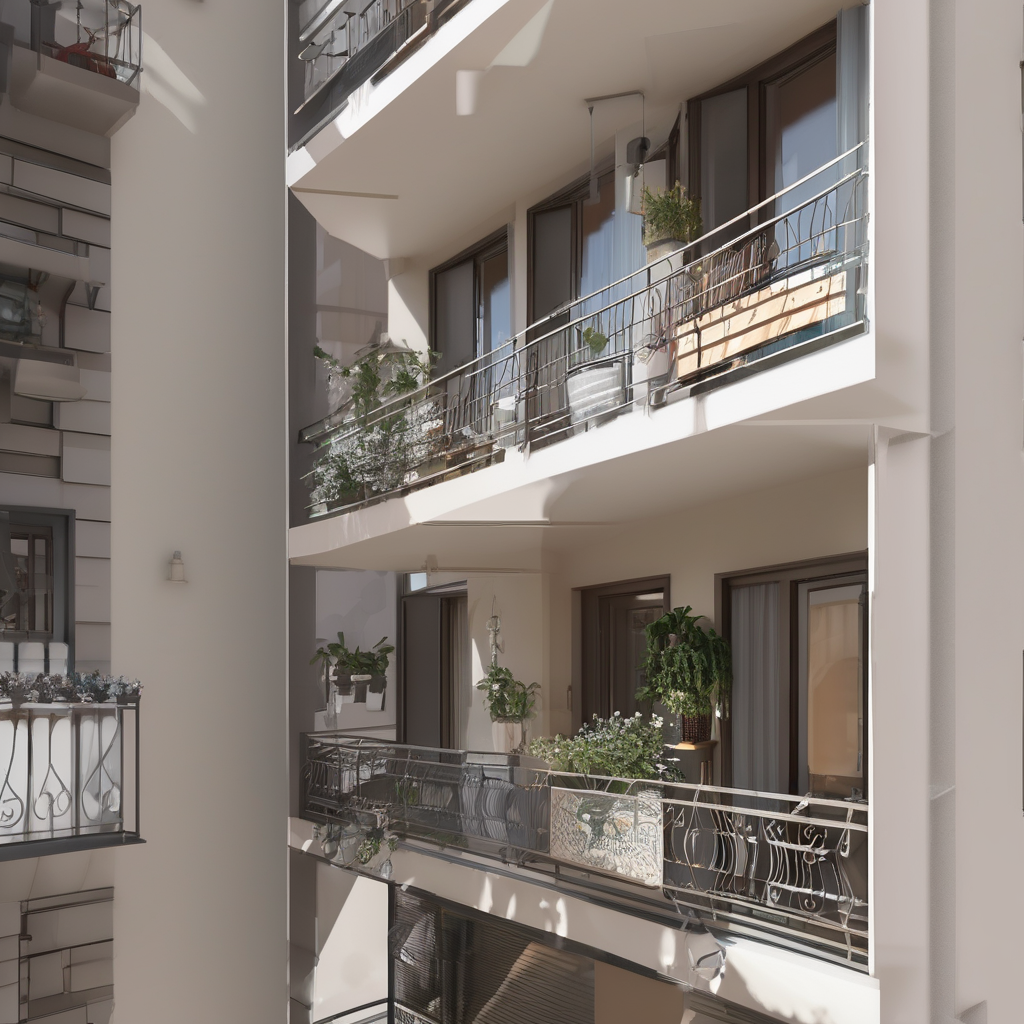

In [3]:
result = pipeline("balcony")   # or reuse the output if you already assigned it
image = result.images[0]
image.save(r"c:\Users\hiroo\3D_facade_reconstruction\runs\sdxl_test\balcony.png")
image  # display in the notebook

In [3]:
%pip install datasets

   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 559.1/559.1 kB 9.4 MB/s  0:00:00
   ---------------------------------------- 0.0/28.6 MB ? eta -:--:--
   --- ------------------------------------ 2.6/28.6 MB 12.6 MB/s eta 0:00:03
   ------- -------------------------------- 5.5/28.6 MB 13.2 MB/s eta 0:00:02
   ----------- ---------------------------- 8.4/28.6 MB 13.3 MB/s eta 0:00:02
   --------------- ------------------------ 11.3/28.6 MB 13.4 MB/s eta 0:00:02
   ------------------- -------------------- 13.9/28.6 MB 13.4 MB/s eta 0:00:02
   ----------------------- ---------------- 16.8/28.6 MB 13.4 MB/s eta 0:00:01
   --------------------------- ------------ 19.7/28.6 MB 13.4 MB/s eta 0:00:01
   ------------------------------- -------- 22.3/28.6 MB 13.4 MB/s eta 0:00:01
   ----------------------------------- ---- 25.2/28.6 MB 13.3 MB/s eta 0:00:01
   -------------------------------------- - 27.8/28.6 MB 13.3 MB/s eta 0:0

In [4]:
from datasets import load_dataset
ds =load_dataset("hanjy/facade_asset")

c:\Users\hiroo\anaconda3\envs\glodon\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 200 examples [00:00, 7633.15 examples/s]


In [5]:
ds.save_to_disk("../runs/balcony_clf/crops/unlabeled")

Saving the dataset (1/1 shards): 100%|██████████| 200/200 [00:00<00:00, 258.24 examples/s]


In [ ]:
from pathlib import Path
out = Path("../runs/balcony_clf/crops/unlabeled")
out.mkdir(parents=True, exist_ok=True)
for i, ex in enumerate(ds["train"]):
    ex["image"].save(out / f"{i:04d}.png")

In [ ]:
import sys
from pathlib import Path
import torch
from PIL import Image

ROOT = Path(r"C:\Users\hiroo\3D_facade_reconstruction")
sys.path.insert(0, str(ROOT))

import run_pipeline as rp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
src_dir = ROOT / "runs/balcony_clf/crops/unlabeled"
out_dir = ROOT / "runs/balcony_clf/crops/unlabeled_cropped"
out_dir.mkdir(parents=True, exist_ok=True)

for img_path in sorted(src_dir.glob("*.jpg")):
    facade = Image.open(img_path).convert("RGB")
    dets = rp.detect_windows(
        facade,
        prompt="balcony",
        threshold=0.35,
        min_side=20,
        max_side_frac=0.95,
        device=device,
    )
    if not dets:
        print(f"skip (no det): {img_path.name}")
        continue
    box = max(
        dets,
        key=lambda d: (d["box_xyxy"][2] - d["box_xyxy"][0])
        * (d["box_xyxy"][3] - d["box_xyxy"][1]),
    )["box_xyxy"]
    facade.crop(tuple(box)).save(out_dir / img_path.name)
    print(f"saved {img_path.name}")

loading SAM3…


Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 4495.20it/s]


SAM3 raw detections: 2
after size filter: 2
saved 0000.png
loading SAM3…


Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 6228.45it/s]


SAM3 raw detections: 1
after size filter: 1
saved 0001.png
loading SAM3…


...

SAM3 raw detections: 2
after size filter: 2
saved 0197.png
loading SAM3…


Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 4771.35it/s]


SAM3 raw detections: 1
after size filter: 1
saved 0198.png
loading SAM3…


Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 6214.62it/s]


SAM3 raw detections: 2
after size filter: 2
saved 0199.png
